In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('https://drive.google.com/uc?export=download&id=1pkLk2s89-Etn7zIuYV88L_FvDH3sI8qx')
df.head()

,Unnamed: 0,source,name,description,neighborhood_overview,host_name,host_since,host_location,host_about,host_response_time,...,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Precio Venta
0,0,city scrape,Nice room with superb city view,Our cool and comfortable one bedroom apartment...,It is very center of Bangkok and easy access t...,Nuttee,08/05/2010,"Bangkok, Thailand","Hi All, I am nuttee patranavik from Bangkok, T...",within an hour,...,0.0,4.86,4.95,4.82,4.97,4.91,4.66,4.75,0.43,4.95
1,1,previous scrape,"Easy going landlord,easy place",Our cool and comfortable one bedroom apartment...,It is very center of Bangkok and easy access t...,Emy,08/05/2010,"Bangkok, Thailand","Hi All, I am nuttee patranavik from Bangkok, T...",within an hour,...,0.0,4.70,4.70,4.70,4.80,4.80,4.60,4.70,1.00,4.70
2,2,previous scrape,modern-style apartment in Bangkok,A modern-style apartment situated in a cool ne...,Ramkumheang neigbourhood - hip place with food...,Familyroom,12/05/2010,"Bangkok, Thailand",Welcome to Familyroom Apartment.\r\n\r\nA Chic...,within an hour,...,0.0,4.70,4.70,4.70,4.80,4.80,4.60,4.70,1.00,4.70
3,3,city scrape,Spacious one bedroom at The Kris Condo Bldg. 3,Cozy and clean apartment at MRT Sutthisarn sta...,"There is McDonald's, Au bon Pain and Max Value...",Sirilak,27/06/2010,"Bangkok, Thailand",from Bangkok but I'm in and out of the city a ...,within an hour,...,0.0,4.83,5.00,4.67,4.50,4.83,4.83,5.00,0.06,5.00
4,4,city scrape,Condo with Chaopraya River View,at a size of 25sqm for your vacation in BKK.<b...,"There is McDonald's, Au bon Pain and Max Value...",Athitaya,03/09/2010,"Bangkok, Thailand","Full-time legal consultant from Bangkok, Thail...",within an hour,...,0.0,5.00,5.00,5.00,5.00,5.00,5.00,5.00,0.01,5.00


In [3]:
df = df[df['room_type'] == 'Shared room']

In [4]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' Half-bath', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' bath', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' baths', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' Half-', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' Shared half-', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' shared half-', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' shared','', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' private bath', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' private', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' shared baths', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' Private half-', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' hared', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace(' S half-', '', regex=False)
df['bathrooms_text'] = pd.to_numeric(df['bathrooms_text'], errors='coerce')

<ipython-input-4-2af7908ae421>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['bathrooms_text'] = df['bathrooms_text'].str.replace(' Half-bath', '', regex=False)
<ipython-input-4-2af7908ae421>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['bathrooms_text'] = df['bathrooms_text'].str.replace(' bath', '', regex=False)
<ipython-input-4-2af7908ae421>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead



In [5]:
df = df.dropna(subset=['bathrooms_text'])

<ipython-input-6-45df8fff4c8a>:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


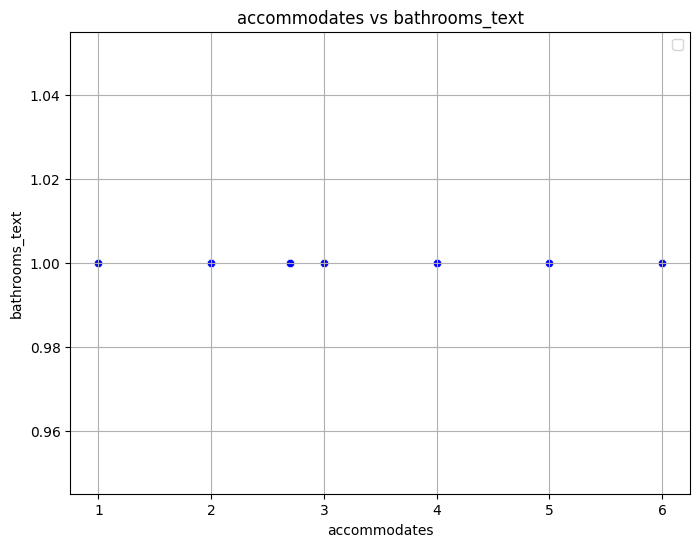

In [6]:
from turtle import color

plt.figure(figsize=(8, 6))
sns.scatterplot(y='bathrooms_text', x='accommodates',  color = 'blue', data=df)
plt.title('accommodates vs bathrooms_text')
plt.xlabel('accommodates')
plt.ylabel('bathrooms_text')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
indep= df[['bathrooms_text']]
dep = df[['accommodates']]

In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [9]:
model.fit(indep, dep)

LinearRegression()

In [10]:
type(model)

sklearn.linear_model._base.LinearRegression

In [11]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['bathrooms_text'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([[0.]]),
 'rank_': 0,
 'singular_': array([0.]),
 'intercept_': array([1.93933649])}

In [12]:
m = model.coef_
b = model.intercept_
print('Pendiente:', m)
print('Intercepto:', b)

# Entonce, el modelo lineal sería:
print(f'y = {m[0]}x + {b}')

Pendiente: [[0.]]
Intercepto: [1.93933649]
y = [0.]x + [1.93933649]


In [13]:
r2 = model.score(indep, dep)
r2

0.0

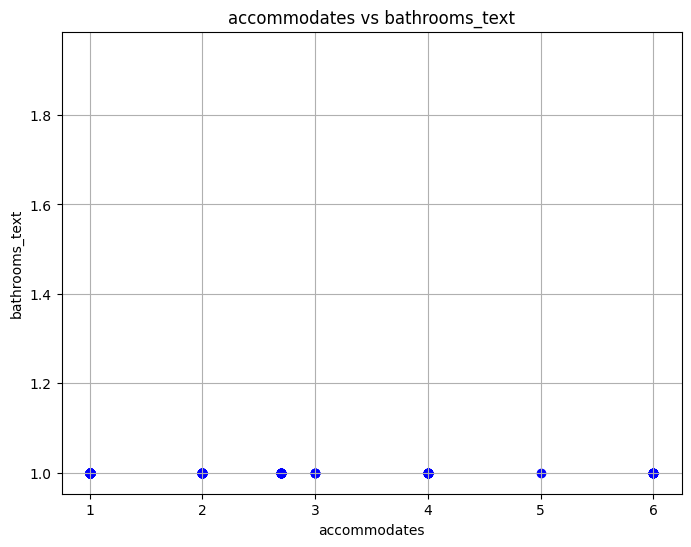

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(dep, indep, color='blue')
plt.plot(indep, model.predict(indep), color='red')
plt.title('accommodates vs bathrooms_text')
plt.xlabel('accommodates')
plt.ylabel('bathrooms_text')
plt.grid(True)
plt.show()

In [15]:
yPred = model.predict(df[['bathrooms_text']])
yPred

array([[1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.93933649],
       [1.939

In [16]:
df['Predicciones'] = yPred
df.head()

,Unnamed: 0,source,name,description,neighborhood_overview,host_name,host_since,host_location,host_about,host_response_time,...,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Precio Venta,Predicciones
217,217,city scrape,S1 hostel (Dorm) Sathorn Bangkok,"Stylish budget hostel in the midst of Bangkok,...",Our hostel is located on small greenery road. ...,S1,19/11/2013,"Bangkok, Thailand",We are very welcome all our guests as our own ...,within an hour,...,4.53,4.61,4.73,4.73,4.62,4.37,4.59,0.76,4.61,1.939336
229,229,previous scrape,BANGKOK HUB : Standard Double Room,A room with minimalism & rustic design in Cult...,"Taking AIRPORT LINK to PHAYATHAI, then Sky Tra...",Kriengkrai,06/09/2013,"Bangkok, Thailand",My inspiration is to have a place where friend...,within an hour,...,5.00,5.00,5.00,5.00,5.00,4.50,4.50,0.02,5.00,1.939336
277,277,previous scrape,k79room near BTS Onnut,k79room HOSTEL is the best budget hostel becau...,"7-11, Tesco Lotus, Big C, Massage, BTS On Nut,...",Warut,21/02/2014,"Bangkok, Thailand","Our Aries building is a low rise, boutique bui...",within an hour,...,4.80,4.67,4.50,4.90,4.67,4.67,4.80,0.03,4.67,1.939336
360,360,city scrape,Room in awesome house,nice room in beautiful house with garden locat...,The house is ideally located in a dead end soi...,Benjamin,01/10/2013,"Bangkok, Thailand",I will personally welcome my guests and make s...,within a few hours,...,4.70,4.70,4.70,4.80,4.80,4.60,4.70,1.00,4.70,1.939336
366,366,city scrape,Suneta Hostel Khaosan 1 Bed in 8 Bunk Mixed Dorm,Has designed by wooden and Thai style with cur...,"We are located in ancient city area, for sight...",Suneta Hostel Khaosan,26/05/2014,"Bangkok, Thailand",Suneta Hostel Khaosan - The Bangkok nostalgia\...,within a few hours,...,4.67,4.67,5.00,4.67,4.67,4.67,4.80,0.02,4.67,1.939336


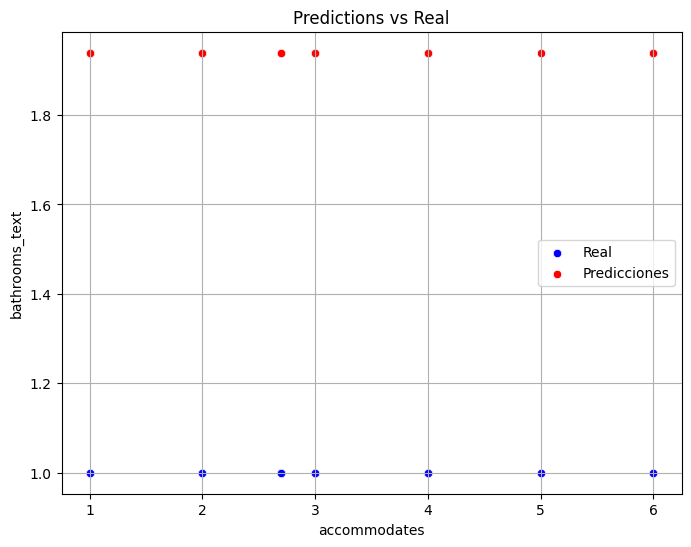

In [17]:
plt.figure(figsize=(8, 6 ))
sns.scatterplot(x='accommodates', y='bathrooms_text', color='blue', data=df, label='Real')
sns.scatterplot(x='accommodates', y='Predicciones', color='red', data=df, label='Predicciones')
#sns.lineplot(x='alcohol', y='Predicciones', color='red', data=df, label='Predicciones')
plt.title('Predictions vs Real')
plt.xlabel('accommodates')
plt.ylabel('bathrooms_text')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
coefDe = model.score(indep, dep)
coefDe

0.0

In [19]:
coefCo = np.sqrt(coefDe)
coefCo

0.0